# Аналитика бразильского маркетплейса Olist

## Бизнес-задача

Цель проекта — определить точки роста бразильского маркетплейса Olist на основе анализа продаж, удержания клиентов и качества доставки.

**Основные вопросы**

1. Как меняются количество заказов и GMV со временем?
2. Какие категории товаров создают наибольший GMV?
3. Как часто клиенты возвращаются после первой покупки?
4. Какие клиентские сегменты следует считать приоритетными?
5. Насколько сильно опоздания доставки связаны с плохими отзывами?

Проект рассчитан на портфолио аналитика уровня Junior / Junior+. В нём используются описательная аналитика, когортный анализ, RFM-сегментация и два базовых статистических теста.

## 1. Настройка окружения и загрузка данных

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Папка с данными найдена:", DATA_DIR.exists())

Папка с данными найдена: True


In [2]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "клиенты": customers,
    "заказы": orders,
    "товары_в_заказах": items,
    "платежи": payments,
    "отзывы": reviews,
    "товары": products,
    "перевод_категорий": category_translation,
}

pd.DataFrame(
    {
        "строки": {name: len(table) for name, table in tables.items()},
        "столбцы": {name: table.shape[1] for name, table in tables.items()},
        "дубли": {name: table.duplicated().sum() for name, table in tables.items()},
        "пропуски": {name: int(table.isna().sum().sum()) for name, table in tables.items()},
    }
).sort_values("строки", ascending=False)

,строки,столбцы,дубли,пропуски
товары_в_заказах,112650,7,0,0
платежи,103886,5,0,0
клиенты,99441,5,0,0
заказы,99441,8,0,4908
отзывы,99224,7,0,145903
товары,32951,9,0,2448
перевод_категорий,71,2,0,0


### Особенности качества данных

- Пропуски в датах доставки ожидаемы для отменённых и недоступных заказов.
- Один заказ может содержать несколько товаров, платежей или записей с отзывами.
- Поэтому перед объединением с таблицей заказов все таблицы со связью «один ко многим» необходимо агрегировать.
- Основная единица анализа в проекте — **один заказ**.

## 2. Создание аналитической витрины на уровне заказа

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

order_items = (
    items.groupby("order_id", as_index=False)
    .agg(
        items_qty=("order_item_id", "count"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        products_cnt=("product_id", "nunique"),
        sellers_cnt=("seller_id", "nunique"),
    )
)

payment_by_order = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_types_cnt=("payment_type", "nunique"),
    )
)

reviews_by_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

items_with_category = (
    items[["order_id", "product_id", "price"]]
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

main_category_by_order = (
    items_with_category.sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
    [["order_id", "product_category_name_english"]]
)

mart = (
    orders.merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(payment_by_order, on="order_id", how="left")
    .merge(reviews_by_order, on="order_id", how="left")
    .merge(main_category_by_order, on="order_id", how="left")
)

mart["gmv"] = mart["product_revenue"].fillna(0) + mart["freight_value"].fillna(0)
mart["purchase_month"] = mart["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
mart["delivery_days"] = (
    mart["order_delivered_customer_date"] - mart["order_purchase_timestamp"]
).dt.total_seconds() / 86_400
mart["delay_days"] = (
    mart["order_delivered_customer_date"] - mart["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

mart["is_late"] = mart["delay_days"].gt(0).where(mart["delay_days"].notna())
mart["bad_review"] = mart["review_score"].le(2).where(mart["review_score"].notna())

delivered = mart.loc[mart["order_status"].eq("delivered")].copy()

print("Заказов в витрине:", mart["order_id"].nunique())
print("Доставленных заказов:", delivered["order_id"].nunique())
print("Одна строка соответствует одному заказу:", mart["order_id"].is_unique)

Заказов в витрине: 99441
Доставленных заказов: 96478
Одна строка соответствует одному заказу: True


## 3. Основные показатели

In [4]:
delivered_with_items = delivered.loc[delivered["product_revenue"].notna()].copy()

total_orders = delivered["order_id"].nunique()
unique_customers = delivered["customer_unique_id"].nunique()
product_revenue = delivered_with_items["product_revenue"].sum()
gmv = delivered_with_items["gmv"].sum()
aov = gmv / total_orders
average_review = delivered["review_score"].mean()
late_delivery_share = delivered["is_late"].mean()

kpis = pd.Series(
    {
        "доставленные_заказы": total_orders,
        "уникальные_клиенты": unique_customers,
        "выручка_от_товаров": product_revenue,
        "gmv_с_учётом_доставки": gmv,
        "средний_чек": aov,
        "средняя_оценка": average_review,
        "доля_опозданий": late_delivery_share,
    }
)

kpis

доставленные_заказы      9.647800e+04
уникальные_клиенты       9.335800e+04
выручка_от_товаров       1.322150e+07
gmv_с_учётом_доставки    1.541977e+07
средний_чек              1.598268e+02
средняя_оценка           4.156187e+00
доля_опозданий           8.112367e-02
dtype: float64

**Интерпретация:** Olist преимущественно является маркетплейсом одной покупки. Далее проверим, зависит ли рост главным образом от новых клиентов и связано ли качество доставки с удовлетворённостью покупателей.

## 4. Динамика продаж

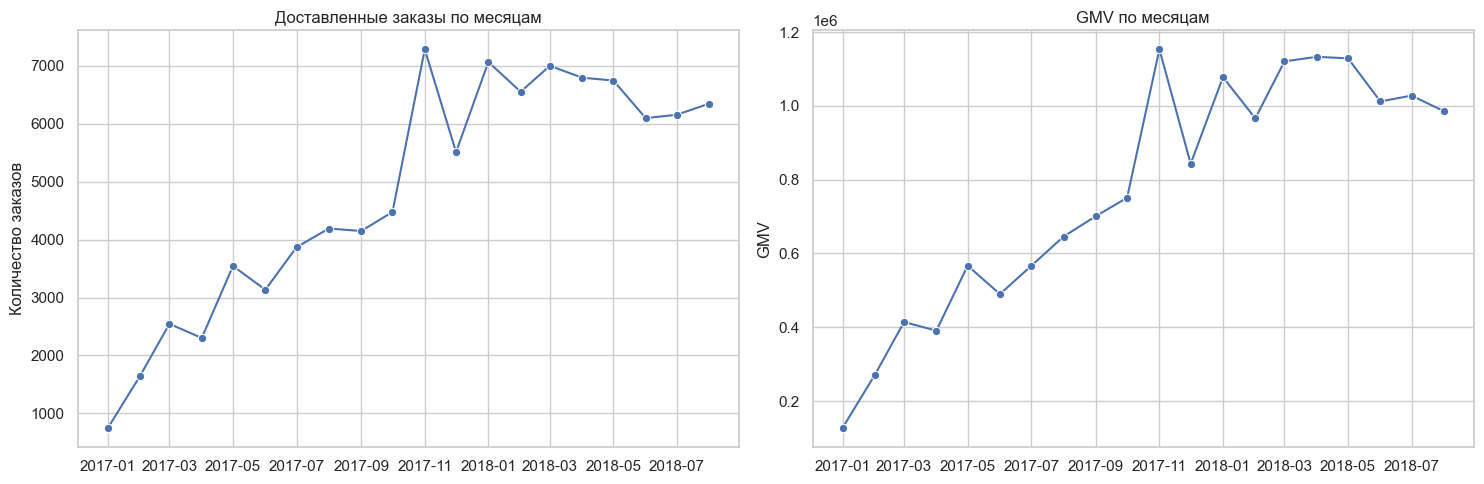

In [5]:
monthly_sales = (
    delivered.groupby("purchase_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        gmv=("gmv", "sum"),
    )
)

# Убираем неполные крайние месяцы из графика динамики.
monthly_sales_complete = monthly_sales.loc[
    monthly_sales["purchase_month"].between("2017-01-01", "2018-08-01")
].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly_sales_complete, x="purchase_month", y="orders", marker="o", ax=axes[0])
sns.lineplot(data=monthly_sales_complete, x="purchase_month", y="gmv", marker="o", ax=axes[1])
axes[0].set_title("Доставленные заказы по месяцам")
axes[1].set_title("GMV по месяцам")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[0].set_ylabel("Количество заказов")
axes[1].set_ylabel("GMV")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

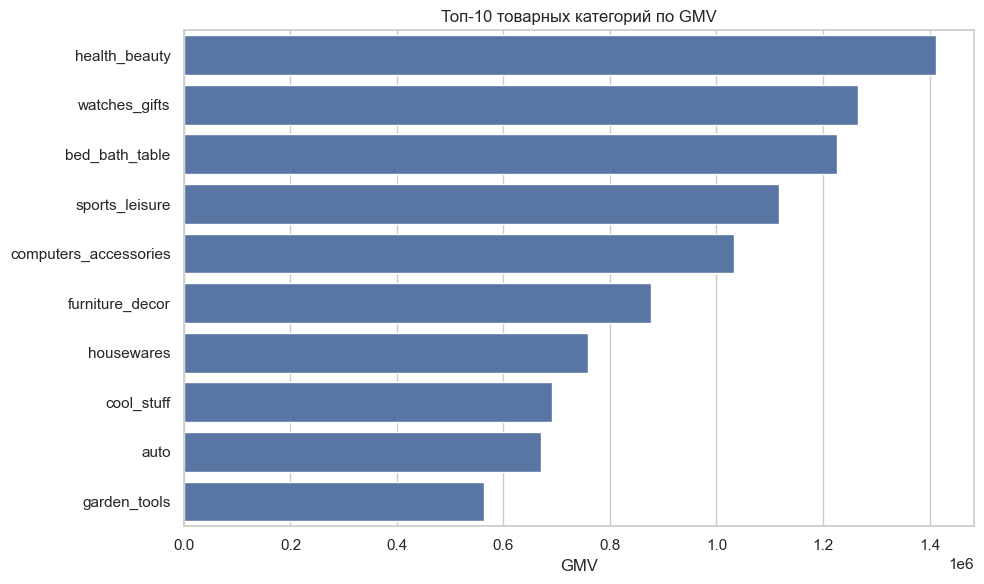

,категория,заказы,gmv
43,health_beauty,8613,1412899.75
70,watches_gifts,5478,1265646.64
7,bed_bath_table,9184,1226459.39
65,sports_leisure,7493,1117692.21
15,computers_accessories,6512,1032733.64
39,furniture_decor,6188,876877.44
49,housewares,5680,757890.31
20,cool_stuff,3530,692050.84
5,auto,3793,669810.68
42,garden_tools,3400,563327.95


In [6]:
category_sales = (
    delivered.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english", as_index=False)
    .agg(orders=("order_id", "nunique"), gmv=("gmv", "sum"))
    .sort_values("gmv", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_sales, y="product_category_name_english", x="gmv")
plt.title("Топ-10 товарных категорий по GMV")
plt.xlabel("GMV")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_categories.png", dpi=150, bbox_inches="tight")
plt.show()

category_sales.rename(
    columns={
        "product_category_name_english": "категория",
        "orders": "заказы",
        "gmv": "gmv",
    }
)

## 5. Повторные покупки и когортный retention

In [7]:
orders_per_customer = (
    delivered.groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customer_rate = orders_per_customer.gt(1).mean()
print(f"Доля повторных клиентов: {repeat_customer_rate:.2%}")
print(
    orders_per_customer.value_counts()
    .sort_index()
    .head(10)
    .rename_axis("количество_заказов")
    .rename("клиенты")
)

Доля повторных клиентов: 3.00%
количество_заказов
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: клиенты, dtype: int64


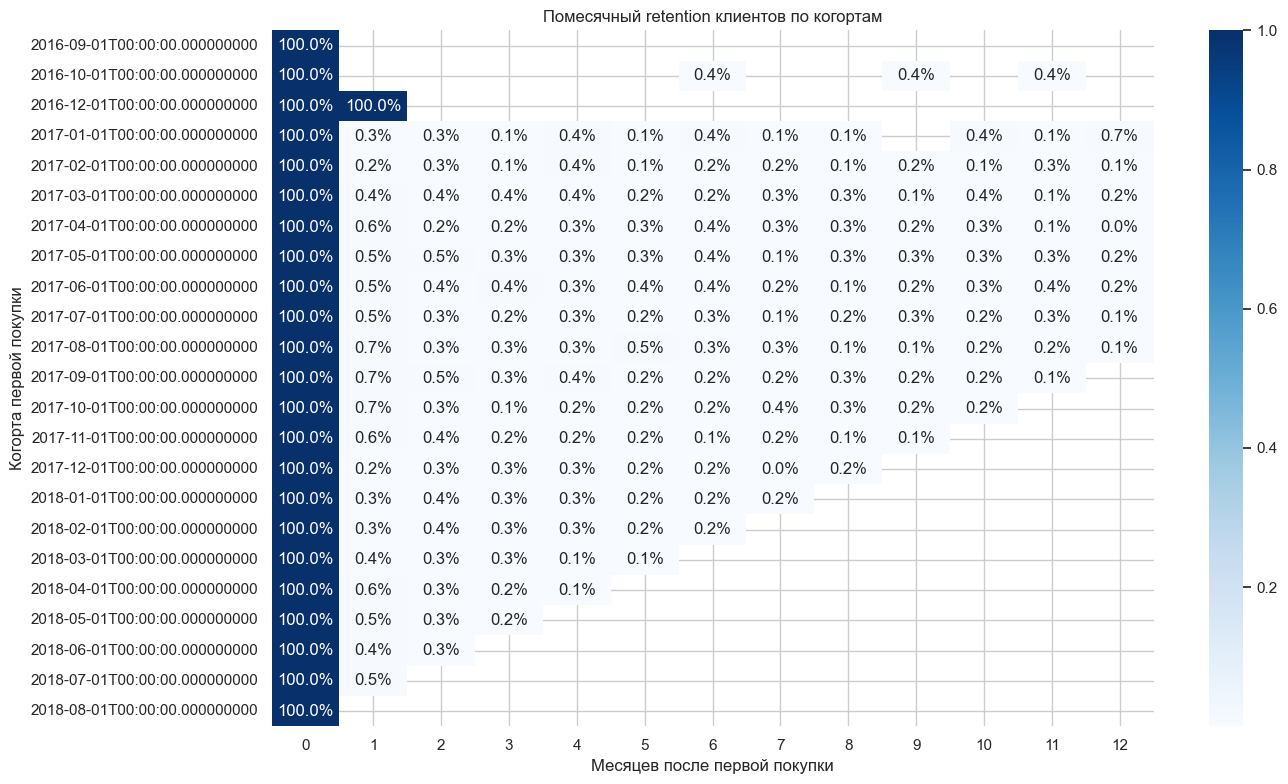

In [8]:
cohort_df = (
    delivered[
        ["customer_unique_id", "order_id", "purchase_month"]
    ]
    .dropna()
    .drop_duplicates()
)

first_orders = (
    cohort_df.groupby("customer_unique_id", as_index=False)["purchase_month"]
    .min()
    .rename(columns={"purchase_month": "cohort_month"})
)

cohort = cohort_df.merge(first_orders, on="customer_unique_id", how="left")
cohort["cohort_index"] = (
    (cohort["purchase_month"].dt.year - cohort["cohort_month"].dt.year) * 12
    + cohort["purchase_month"].dt.month
    - cohort["cohort_month"].dt.month
)

cohort_counts = (
    cohort.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index(name="active_customers")
)

cohort_sizes = (
    cohort_counts.loc[cohort_counts["cohort_index"].eq(0), ["cohort_month", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)

cohort_retention = cohort_counts.merge(cohort_sizes, on="cohort_month", how="left")
cohort_retention["retention"] = (
    cohort_retention["active_customers"] / cohort_retention["cohort_size"]
)

retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention",
)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_pivot.iloc[:, :13], annot=True, fmt=".1%", cmap="Blues")
plt.title("Помесячный retention клиентов по когортам")
plt.xlabel("Месяцев после первой покупки")
plt.ylabel("Когорта первой покупки")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()

**Интерпретация:** `cohort_index = 0` — месяц первой покупки клиента. Индекс `1` означает следующий месяц, индекс `2` — два месяца спустя и так далее. Индекс позволяет сравнивать разные календарные когорты на одинаковом этапе жизни клиента.

## 6. RFM-сегментация клиентов

In [9]:
snapshot_date = delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    delivered.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("gmv", "sum"),
    )
    .reset_index()
)

rfm["R"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1],
).astype(int)

# Frequency сильно сконцентрирована на одном заказе, поэтому бизнес-правила понятнее квантилей.
rfm["F"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["M"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm["rfm_score"] = rfm[["R", "F", "M"]].sum(axis=1)

rfm["segment"] = np.select(
    [
        (rfm["R"] >= 4) & (rfm["F"] >= 2) & (rfm["M"] >= 4),
        (rfm["R"] >= 4) & (rfm["F"] == 1),
        (rfm["R"] <= 2) & (rfm["F"] >= 2),
        (rfm["R"] <= 2),
    ],
    ["Чемпионы", "Новые клиенты", "Под риском", "Неактивные"],
    default="Обычные",
)

segment_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        average_recency=("recency", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary=("monetary", "mean"),
    )
    .sort_values("customers", ascending=False)
)

segment_summary.rename(
    columns={
        "segment": "сегмент",
        "customers": "клиенты",
        "average_recency": "средняя_давность",
        "average_frequency": "средняя_частота",
        "average_monetary": "средняя_ценность",
    }
)

,сегмент,клиенты,средняя_давность,средняя_частота,средняя_ценность
0,Неактивные,36347,394.931714,1.000000,161.786499
1,Новые клиенты,36135,90.408800,1.000000,164.317359
2,Обычные,18891,218.337939,1.046318,155.696277
3,Под риском,996,381.404618,2.081325,293.945522
4,Чемпионы,989,88.738119,2.180991,371.773509


## 7. Качество доставки и отзывы

In [10]:
delivery_analysis = (
    delivered[
        ["order_id", "is_late", "delay_days", "delivery_days", "review_score", "bad_review"]
    ]
    .dropna(subset=["delay_days", "review_score"])
    .copy()
)

delivery_analysis["is_late"] = delivery_analysis["is_late"].astype(bool)
delivery_analysis["bad_review"] = delivery_analysis["bad_review"].astype(int)

delivery_metrics = (
    delivery_analysis.groupby("is_late")
    .agg(
        orders=("order_id", "nunique"),
        average_review=("review_score", "mean"),
        bad_review_share=("bad_review", "mean"),
        average_delivery_days=("delivery_days", "mean"),
    )
)

delivery_metrics.rename(
    index={False: "Вовремя", True: "С опозданием"},
    columns={
        "orders": "заказы",
        "average_review": "средняя_оценка",
        "bad_review_share": "доля_плохих_отзывов",
        "average_delivery_days": "среднее_время_доставки",
    }
)

,заказы,средняя_оценка,доля_плохих_отзывов,среднее_время_доставки
is_late,,,,
Вовремя,88163,4.294292,0.091875,10.877733
С опозданием,7661,2.566506,0.539877,31.378793


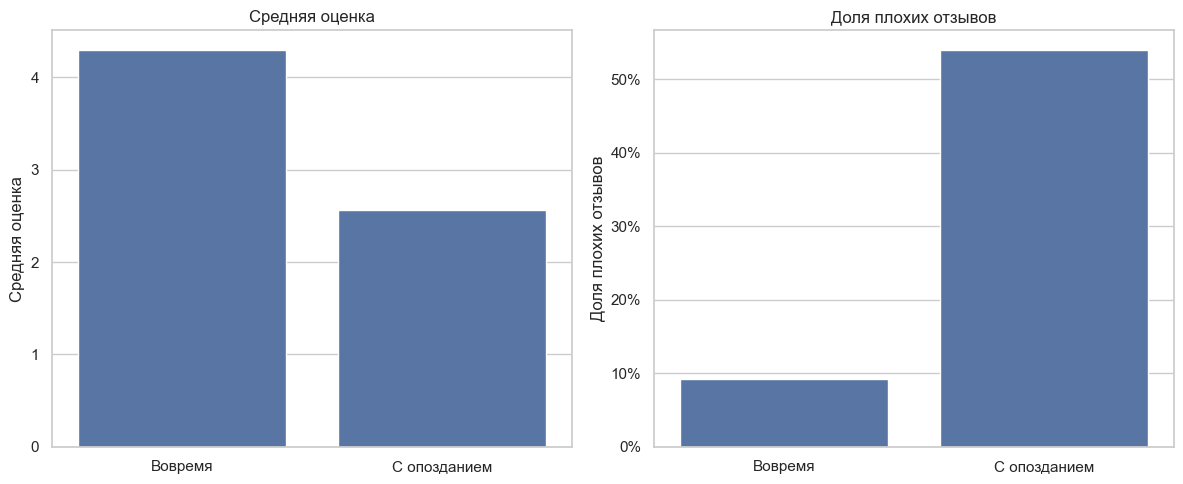

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_data = delivery_metrics.reset_index()
plot_data["delivery_status"] = plot_data["is_late"].map({False: "Вовремя", True: "С опозданием"})

sns.barplot(data=plot_data, x="delivery_status", y="average_review", ax=axes[0])
sns.barplot(data=plot_data, x="delivery_status", y="bad_review_share", ax=axes[1])
axes[0].set_title("Средняя оценка")
axes[1].set_title("Доля плохих отзывов")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[0].set_ylabel("Средняя оценка")
axes[1].set_ylabel("Доля плохих отзывов")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delivery_reviews.png", dpi=150, bbox_inches="tight")
plt.show()

### Базовые статистические тесты

Тесты ниже отвечают на вопрос, являются ли наблюдаемые различия статистически значимыми:

- **Критерий хи-квадрат:** связь между статусом доставки и плохим отзывом.
- **t-критерий Уэлча:** различие средней оценки.

Это наблюдательные данные, а не рандомизированный эксперимент. Статистическая значимость показывает наличие связи, но не доказывает причинность.

In [12]:
contingency_table = pd.crosstab(
    delivery_analysis["is_late"],
    delivery_analysis["bad_review"],
)

chi2_stat, chi2_p_value, dof, expected = chi2_contingency(contingency_table)

late_reviews = delivery_analysis.loc[
    delivery_analysis["is_late"], "review_score"
]
on_time_reviews = delivery_analysis.loc[
    ~delivery_analysis["is_late"], "review_score"
]

t_stat, t_p_value = ttest_ind(
    late_reviews,
    on_time_reviews,
    equal_var=False,
)

statistical_results = pd.DataFrame(
    {
        "тест": ["Хи-квадрат: доля плохих отзывов", "t-критерий Уэлча: средняя оценка"],
        "статистика": [chi2_stat, t_stat],
        "p_value": [chi2_p_value, t_p_value],
        "вывод_при_alpha_0_05": [
            "Отклоняем H0" if chi2_p_value < 0.05 else "Не отклоняем H0",
            "Отклоняем H0" if t_p_value < 0.05 else "Не отклоняем H0",
        ],
    }
)

statistical_results

,тест,статистика,p_value,вывод_при_alpha_0_05
0,Хи-квадрат: доля плохих отзывов,12696.532368,0.0,Отклоняем H0
1,t-критерий Уэлча: средняя оценка,-89.384390,0.0,Отклоняем H0


## 8. Итоговые выводы и рекомендации

In [13]:
summary = {
    "доставленные_заказы": total_orders,
    "уникальные_клиенты": unique_customers,
    "gmv": round(gmv, 2),
    "средний_чек": round(aov, 2),
    "доля_повторных_клиентов": round(repeat_customer_rate, 4),
    "доля_плохих_отзывов_вовремя": round(delivery_metrics.loc[False, "bad_review_share"], 4),
    "доля_плохих_отзывов_с_опозданием": round(delivery_metrics.loc[True, "bad_review_share"], 4),
    "средняя_оценка_вовремя": round(delivery_metrics.loc[False, "average_review"], 2),
    "средняя_оценка_с_опозданием": round(delivery_metrics.loc[True, "average_review"], 2),
}

summary

{'доставленные_заказы': 96478,
 'уникальные_клиенты': 93358,
 'gmv': np.float64(15419773.75),
 'средний_чек': np.float64(159.83),
 'доля_повторных_клиентов': np.float64(0.03),
 'доля_плохих_отзывов_вовремя': np.float64(0.0919),
 'доля_плохих_отзывов_с_опозданием': np.float64(0.5399),
 'средняя_оценка_вовремя': np.float64(4.29),
 'средняя_оценка_с_опозданием': np.float64(2.57)}

### Основные выводы

1. **Retention — главное ограничение роста.** Доля повторных клиентов очень низкая, поэтому рост сильно зависит от привлечения новых покупателей.
2. **Качество доставки тесно связано с удовлетворённостью.** У опоздавших заказов значительно выше доля плохих отзывов и ниже средняя оценка.
3. **Портфель категорий сконцентрирован.** Ведущие категории формируют значительную долю GMV и требуют отдельного мониторинга.
4. **RFM-сегментация выделяет практические клиентские группы.** Недавние покупатели с одним заказом — крупнейшая возможность для CRM, а повторных ценных клиентов необходимо удерживать.

### Бизнес-рекомендации

- Запустить CRM-кампании для стимулирования второй покупки в течение 30–60 дней.
- Отслеживать долю опозданий и плохих отзывов по категориям и штатам.
- Заранее связываться с клиентами по заказам с риском задержки.
- Создать dashboard качества продавцов на основе доставки, отмен и отзывов.

### Ограничения

- Данные Olist являются историческими и наблюдательными; анализ не доказывает причинность.
- GMV включает цену товара и доставку, но не отражает прибыль маркетплейса.
- В данных отсутствуют маркетинговые расходы, маржинальность и реальные экспериментальные группы.
- Крайние месяцы представлены не полностью и исключены из графика динамики продаж.